# Task 10: Exploring Euler's Method

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Defining helper functions for the simulation

In [2]:
def func(y0, t, alpha, beta, delta, gamma):
    dxdt = (alpha * y0[0]) - (beta * y0[0] * y0[1])
    dydt = (delta * y0[0] * y0[1]) - (gamma * y0[1])
    return dxdt, dydt

def loss_metric(y, y_orig):
    eucledian = np.sqrt(np.sum((y_orig - y) ** 2))
    mape = np.mean(np.abs((y_orig - y) / y_orig))
    return eucledian, mape

def plt_euler(t, t_orig, y, y_orig, sample_freq):
    plt.plot(t, y[:, 0], label="Prey")
    plt.plot(t, y[:, 1], label="Predator")
    plt.plot(t_orig, y_orig[:, 0], color="red", linestyle="dotted", label="Analytical Prey")
    plt.plot(t_orig, y_orig[:, 1], color="black", linestyle="dotted", label="Analytical Predator")
    euc, mape = loss_metric(y[:, 0], y_orig[:, 0][0::sample_freq])
    print("Preys Time Series Loss: ", str(round(euc,2)), " (eucledian) ", str(round(mape,2)), " (mape)")
    euc, mape = loss_metric(y[:, 1], y_orig[:, 1][0::sample_freq])
    print("Predators Time Series Loss: ", str(round(euc,2)), " (eucledian) ", str(round(mape,2)), " (mape)")
    plt.legend()
    plt.ylabel("Populations Size")
    plt.xlabel("Time")
    plt.show()

## Running the simulation and exploring the results

In [3]:
# Prey, Predator
y0 = [10, 10]
alpha, beta = 0.1, 0.02
delta, gamma = 0.02, 0.4
end_time = 100
n_samples = 1000
t = np.linspace(0, end_time, n_samples)
y = odeint(func, y0, t, args=(alpha, beta, delta, gamma))

Preys Time Series Loss:  272.87  (eucledian)  1.09  (mape)
Predators Time Series Loss:  133.54  (eucledian)  0.68  (mape)


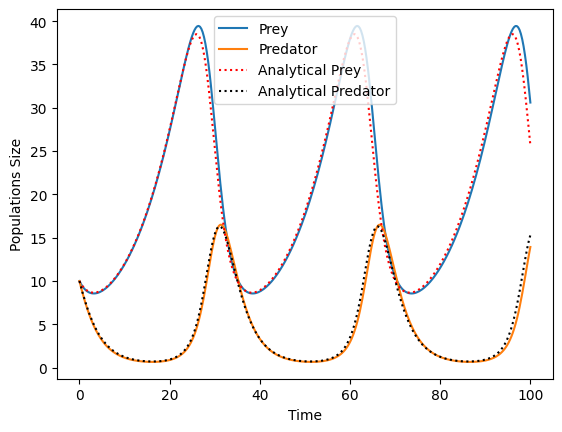

In [4]:
delta_t = 0.3
intervals = np.linspace(0, end_time, int(end_time/delta_t)+1)
preys = [y0[0]]
predators = [y0[1]]
for step in intervals[1:]:
    preys.append(preys[-1] + (alpha * preys[-1] - beta * preys[-1] * predators[-1]) * delta_t)
    predators.append(predators[-1] + (delta * preys[-1] * predators[-1] - gamma * predators[-1]) * delta_t)
    
plt_euler(intervals, t, np.stack((preys, predators), axis=-1), y, int(n_samples/delta_t))